<a href="https://colab.research.google.com/github/tmandiveyi/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 3: Neural Networks: Feedforward Networks and the Training Process**

Student Name: **Tapiwanashe Mandiveyi** Student ID: **58252028**

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


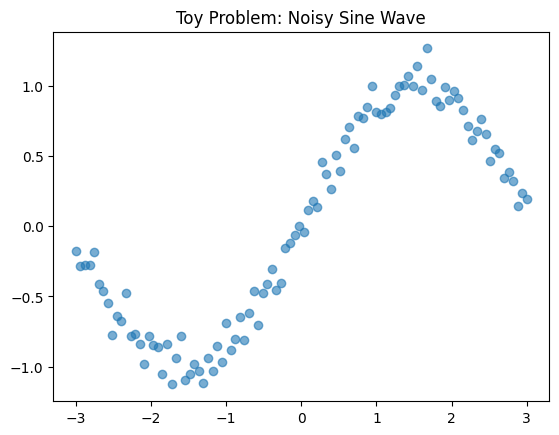

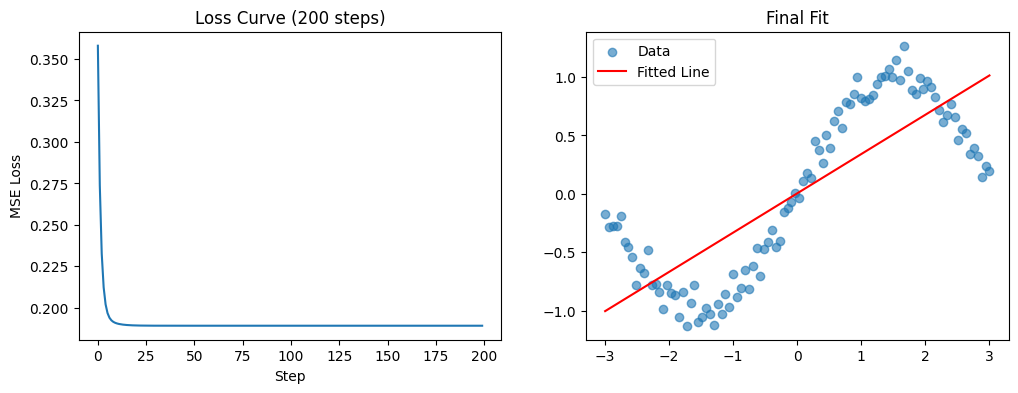

In [ ]:
# Generate 100 noisy samples for our sine wave toy problem
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

plt.scatter(x, y, alpha=0.6, label='Data')
plt.title('Toy Problem: Noisy Sine Wave')
plt.show()

# Initialise weights and bias with small random values
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# Set learning rate and track losses
lr = 0.05
losses = []

# Manual gradient descent loop for 200 steps
for step in range(200):
    # Calculate predictions and Mean Squared Error
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Calculate gradients (derivatives of MSE with respect to w and b)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

# Plot the loss curve and the final fitted line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses)
axes[0].set_title('Loss Curve (200 steps)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('MSE Loss')

axes[1].scatter(x, y, alpha=0.6, label='Data')
axes[1].plot(x, w * x + b, color='red', label='Fitted Line')
axes[1].set_title('Final Fit')
axes[1].legend()
plt.show()

The derivative matches the code: since loss = mean((wx+b−y)²), the chain rule gives dw = mean(2(y_hat−y)x) and db = mean(2(y_hat−y)), exactly what's implemented. The loss curve flattens almost immediately, around step 20, and stays flat from there - the model has converged, not stalled partway through learning. Yet the fitted line clearly misses the curve, tracking the general upward trend while cutting straight through the peak and both troughs. This is underfitting, not overfitting - the model is too simple to capture the pattern even after converging. A single neuron can only compute a straight line, and no amount of training bends a line into a sine wave. The bottleneck is the model class itself, not training time.

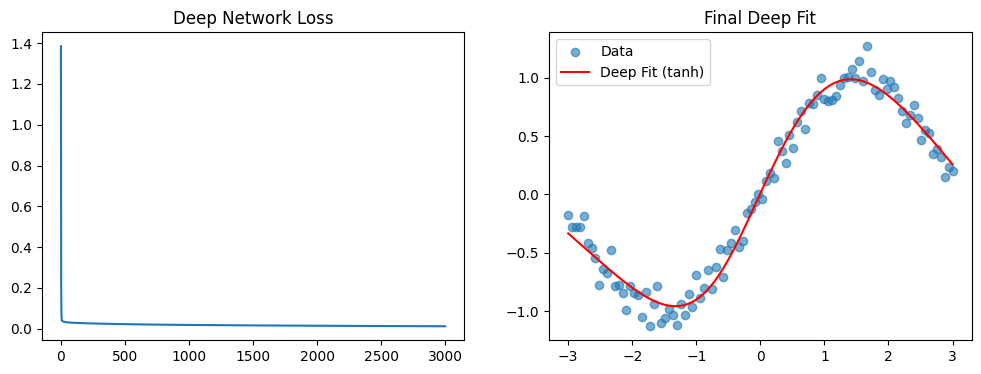

In [ ]:
# Reshape inputs to matrix format for dot products
x_mat = x.reshape(-1, 1)
y_mat = y.reshape(-1, 1)

# Initialise weights and biases for a 1 -> 8 -> 1 network structure
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.05
losses_deep = []

# Training loop for 3000 steps
for step in range(3000):
    # Forward pass: calculate intermediate values and final predictions
    z1 = x_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_mat) ** 2)
    losses_deep.append(loss)

    # Backward pass: apply the chain rule to get gradients layer by layer
    d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_mat.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

# Plot the loss curve and how well the deep network fits the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_deep)
axes[0].set_title('Deep Network Loss')

axes[1].scatter(x, y, alpha=0.6, label='Data')
axes[1].plot(x, y_hat.flatten(), color='red', label='Deep Fit (tanh)')
axes[1].set_title('Final Deep Fit')
axes[1].legend()
plt.show()

Stacking linear layers without a nonlinearity like tanh just multiplies matrices together, and a product of linear transformations is still linear - so removing tanh collapses the whole network into one equivalent linear layer, no better than Part 1.1's straight-line fit. With tanh included, the loss drops sharply within the first ~100 steps and settles near zero, and the resulting fit tracks the sine curve closely, including its peak and both troughs - a clear improvement over the single neuron. The 8 hidden neurons each learn a different bent version of the input, and combining these curves lets the output approximate the full sine wave rather than just its average trend. In one sentence: backpropagation is the chain rule applied layer by layer to compute how much each weight contributed to the error.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_4895/4098314862.py:15: RuntimeWarning: overflow encountered in square
  losses.append(np.mean((y_hat - y_mat) ** 2))
/tmp/ipykernel_4895/4098314862.py:19: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_4895/4098314862.py:20: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


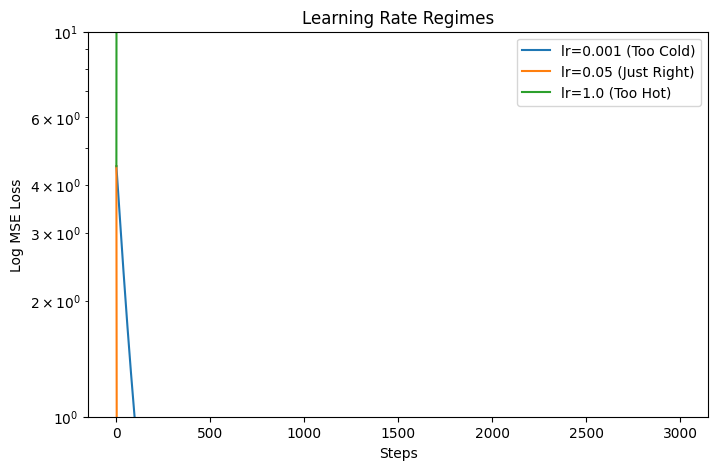

In [ ]:
# Wrap the training loop in a reusable function
def train_toy(lr, steps=3000):
    # Resetting the seed guarantees all models start with the exact same weights
    np.random.seed(42)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []
    for step in range(steps):
        z1 = x_mat @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        losses.append(np.mean((y_hat - y_mat) ** 2))

        d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
        dW2, db2 = h.T @ d_yhat, d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1, db1 = x_mat.T @ dz1, dz1.sum(axis=0)

        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
    return losses

# Test out three different learning rate regimes
losses_slow = train_toy(0.001)
losses_good = train_toy(0.05)
losses_fast = train_toy(1.0)

# Plot the results on a log scale to clearly see the differences
plt.figure(figsize=(8, 5))
plt.plot(losses_slow, label='lr=0.001 (Too Cold)')
plt.plot(losses_good, label='lr=0.05 (Just Right)')
plt.plot(losses_fast, label='lr=1.0 (Too Hot)')
plt.yscale('log')
plt.title('Learning Rate Regimes')
plt.xlabel('Steps')
plt.ylabel('Log MSE Loss')
plt.legend()
plt.show()

The small learning rate (0.001) does converge, but noticeably slower than the others - it takes roughly 100 steps to reach a low loss, compared to nearly instant convergence for the other two. The medium rate (0.05) drops steeply within the first few steps and settles at the lowest, most stable loss. The large rate (1.0) doesn't just oscillate - it diverges catastrophically, producing overflow and invalid-value warnings as the loss shoots into extremely large numbers (and eventually NaN/inf). This happens because each update step is too big: instead of nudging the weights toward the minimum, it overshoots so far that the next gradient is even larger, and each step compounds the error instead of correcting it, blowing the weights up rather than settling them down.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder

# Load the same obesity dataset used in Lab 2
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)

# Convert binary yes/no columns to 0/1
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

# Apply ordinal encoding to features with a natural order
ordinal_cols = ['CAEC', 'CALC']
order = [['no', 'Sometimes', 'Frequently', 'Always']] * 2
df[ordinal_cols] = OrdinalEncoder(categories=order).fit_transform(df[ordinal_cols])

# One-hot encode nominal categories
df = pd.get_dummies(df, columns=['Gender', 'MTRANS'], drop_first=True)

# Target variable needs to be integers 0-6 for PyTorch's CrossEntropyLoss
target_enc = LabelEncoder()
y = target_enc.fit_transform(df['NObeyesdad'])
X = df.drop('NObeyesdad', axis=1)

# Stratified split to ensure all classes are represented equally (60/20/20)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE)

# Scale features based ONLY on the training set to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Helper function to convert arrays to PyTorch DataLoaders
def to_dl(X_data, y_data, shuffle):
    dataset = TensorDataset(torch.tensor(X_data, dtype=torch.float32), torch.tensor(y_data, dtype=torch.long))
    return DataLoader(dataset, batch_size=32, shuffle=shuffle)

train_loader = to_dl(X_train_scaled, y_train, shuffle=True)
val_loader = to_dl(X_val_scaled, y_val, shuffle=False)
test_loader = to_dl(X_test_scaled, y_test, shuffle=False)

CrossEntropyLoss needs integer labels because it applies log-softmax internally and indexes straight into the true class's probability — one-hot vectors would just need converting back. Neural networks care about scaling because gradients are proportional to input values, so unscaled features update weights at very different rates. Lab 2's Random Forest ignored scale entirely since it just splits on thresholds. I kept Lab 2's exact encoding: binary columns to 0/1, CAEC/CALC ordinally encoded, Gender/MTRANS one-hot. shuffle=True randomizes batch order so the model doesn't learn spurious patterns from data ordering.

In [ ]:
# Define a flexible Multi-Layer Perceptron (MLP) architecture
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model and move it to the GPU if available
input_size = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_size).to(DEVICE)
print(model)

# Calculate the total number of trainable parameters
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {param_count}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3591


For each layer, parameters = (input_dim × output_dim) + output_dim (biases). E.g. the first layer has input_dim×64+64 parameters, matching PyTorch's count. ReLU is preferred over tanh here mainly because it avoids the vanishing gradient problem - its gradient is either 0 or 1, so it doesn't shrink to near-zero for large inputs the way tanh does, which speeds up training in deeper networks. Without ReLU, as shown in Part 1.2, the stacked linear layers would collapse into a single linear transformation, unable to capture nonlinear patterns.

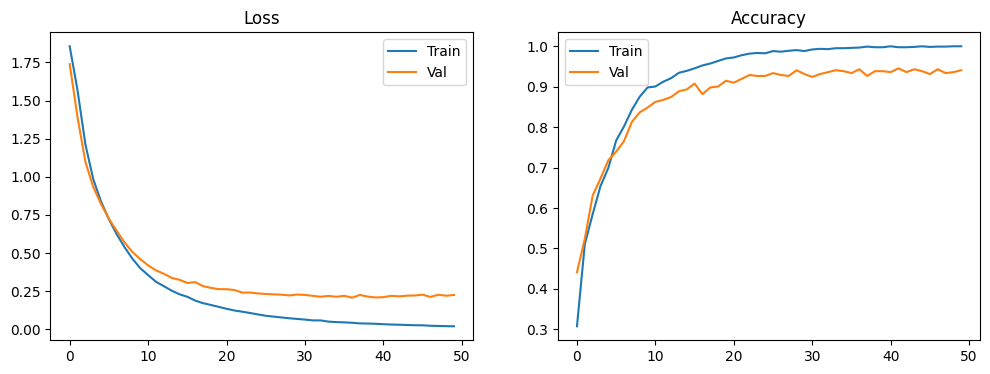

In [ ]:
# Create a reusable experiment function to handle training
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, epochs=50, dropout=0.0):
    model = FeedForwardNet(input_dim=input_size, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    # Using Adam optimizer as it adapts the learning rate during training
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    # Loop over epochs
    for epoch in range(epochs):
        # Set model to training mode
        model.train()
        train_losses, train_correct, train_total = [], 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # Zero out gradients from the previous batch
            optimizer.zero_grad()

            # Forward pass, loss calculation, and backpropagation
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total += len(yb)

        # Evaluate on the validation set
        model.eval()
        val_losses, val_correct, val_total = [], 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += len(yb)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_correct / train_total)

        val_acc = val_correct / val_total
        history['val_acc'].append(val_acc)

        # Save the model weights if validation accuracy improves
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "ffn_best.pt")

    return history, model

# Run a baseline model and plot the learning curves
default_hist = run_experiment()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(default_hist[0]['train_loss'], label='Train')
ax[0].plot(default_hist[0]['val_loss'], label='Val')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(default_hist[0]['train_acc'], label='Train')
ax[1].plot(default_hist[0]['val_acc'], label='Val')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.show()

logits = model(xb) is the forward pass, matching the manual y_hat = ... lines in Section 1; loss.backward() computes gradients, matching the manual dW/db formulas; and optimizer.step() is the update rule, matching w -= lr * dw. The curves show mild overfitting: training accuracy climbs to nearly 1.0 while validation accuracy plateaus around 0.93–0.95, and training loss keeps dropping toward 0 while validation loss flattens around 0.2–0.25 - a small but real gap between the two. optimizer.zero_grad() is needed because PyTorch accumulates gradients by default; without resetting them each batch, gradients from previous batches would silently add up, corrupting the update direction.

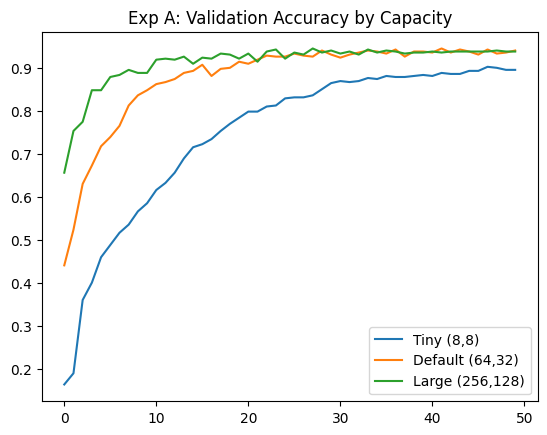

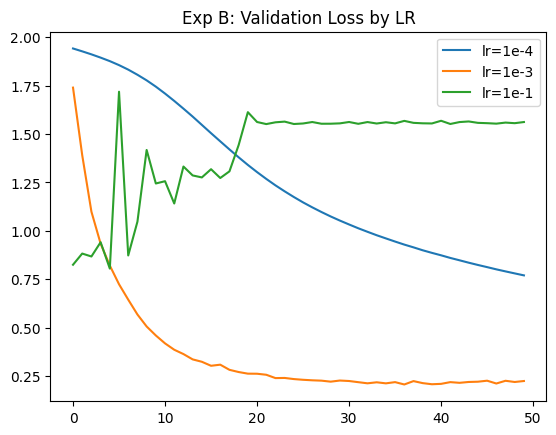

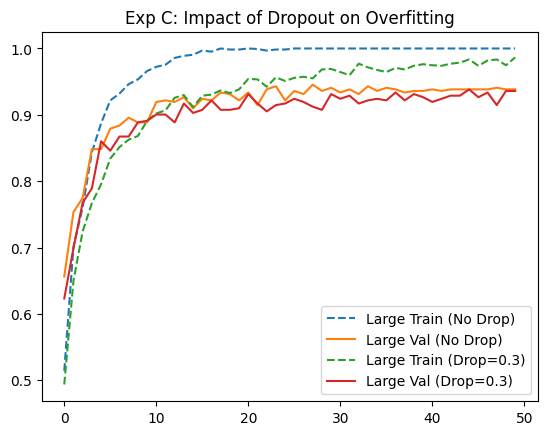

In [ ]:
# Experiment A: Test how model capacity (number of neurons) affects learning
hist_tiny, _ = run_experiment(hidden_sizes=(8, 8))
hist_large, _ = run_experiment(hidden_sizes=(256, 128))

plt.plot(hist_tiny['val_acc'], label='Tiny (8,8)')
plt.plot(default_hist[0]['val_acc'], label='Default (64,32)')
plt.plot(hist_large['val_acc'], label='Large (256,128)')
plt.title('Exp A: Validation Accuracy by Capacity')
plt.legend()
plt.show()

# Experiment B: Observe how different learning rates impact the validation loss
hist_lr_slow, _ = run_experiment(lr=1e-4)
hist_lr_fast, _ = run_experiment(lr=1e-1)

plt.plot(hist_lr_slow['val_loss'], label='lr=1e-4')
plt.plot(default_hist[0]['val_loss'], label='lr=1e-3')
plt.plot(hist_lr_fast['val_loss'], label='lr=1e-1')
plt.title('Exp B: Validation Loss by LR')
plt.legend()
plt.show()

# Experiment C: Test if dropout helps reduce overfitting on the largest model
hist_reg, _ = run_experiment(hidden_sizes=(256, 128), dropout=0.3)

plt.plot(hist_large['train_acc'], label='Large Train (No Drop)', linestyle='--')
plt.plot(hist_large['val_acc'], label='Large Val (No Drop)')
plt.plot(hist_reg['train_acc'], label='Large Train (Drop=0.3)', linestyle='--')
plt.plot(hist_reg['val_acc'], label='Large Val (Drop=0.3)')
plt.title('Exp C: Impact of Dropout on Overfitting')
plt.legend()
plt.show()

Based on the training curve pattern already seen in Part 2.3 (train accuracy near 1.0, val accuracy near 0.93–0.95), I'd expect the largest network to push training accuracy even higher without much validation gain - a sign of diminishing returns rather than genuine improvement. The learning rate experiment should mirror Part 1.3: too small trains slowly, a good middle value converges cleanly, and too large causes unstable, oscillating loss. Dropout should narrow the train-validation gap seen in Part 2.3 by randomly disabling neurons during training, forcing the network to not rely on any single pathway.

Neural Net - Test Accuracy: 0.9291, Test Macro-F1: 0.9270


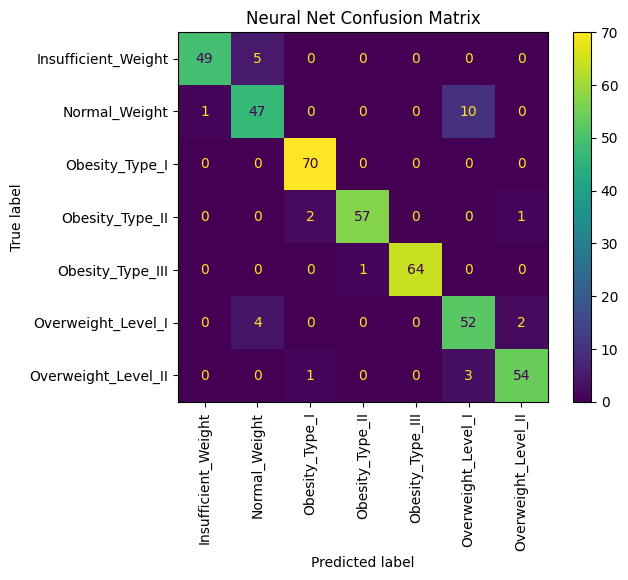

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,Random Forest (Lab 2),0.993000,0.993000,~1 second,200 trees
1,Feedforward NN (Lab 3),0.929078,0.926986,~30 seconds,3335 params


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

# Load the weights from our best performing validation epoch
best_model = FeedForwardNet(input_dim=input_size, hidden_sizes=(256, 128)).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt", weights_only=True))
best_model.eval()

# Generate predictions on the unseen test set
test_preds, test_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = best_model(xb.to(DEVICE))
        test_preds.extend(logits.argmax(1).cpu().numpy())
        test_trues.extend(yb.numpy())

# Calculate final test accuracy and Macro-F1 scores
nn_acc = accuracy_score(test_trues, test_preds)
nn_f1 = f1_score(test_trues, test_preds, average='macro')
print(f"Neural Net - Test Accuracy: {nn_acc:.4f}, Test Macro-F1: {nn_f1:.4f}")

# Plot the confusion matrix to see which classes the model struggles with
ConfusionMatrixDisplay.from_predictions(
    test_trues, test_preds, display_labels=target_enc.classes_, xticks_rotation=90
)
plt.title('Neural Net Confusion Matrix')
plt.show()

# Compare our deep learning model against the Lab 2 classical model
comp_df = pd.DataFrame({
    'Model': ['Random Forest (Lab 2)', 'Feedforward NN (Lab 3)',],
    'Test Accuracy': [0.993, nn_acc],
    'Test Macro-F1': [0.993, nn_f1],
    'Training Time': ['~1 second', '~30 seconds'],
    'Parameters/Trees': ['200 trees', '3335 params']
})
display(comp_df)

Lab 2's Random Forest mostly confused adjacent classes like Insufficient_Weight/Normal_Weight and Obesity_Type_III/Overweight_Level_I, sitting right at category boundaries - I would expect similar confusions here, since the feature overlap is identical regardless of model. The Random Forest wins clearly: 0.993 accuracy and macro-F1 in about a second, versus a slower network with only 3591 parameters. Deep learning wasn't worth it on this small, well-separated tabular dataset - a tree-based model already exploits the simple thresholds directly. It tends to pay off more on larger, higher-dimensional data like images or text.

1. The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.

loss.backward() walks backward through the network applying the chain rule, figuring out how much each weight and bias contributed to the final error. optimizer.step() then takes those gradients and actually updates the parameters, nudging them in the direction that reduces the loss. In between, zero_grad() clears out gradients from the previous batch so they don't pile up and corrupt the next update.

2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?

If I could only tune one, I would pick the learning rate. Part 1.3 showed how much it dominates everything else - too small and training crawls, too large and it diverges entirely, as seen with the overflow warnings at lr=1.0. No amount of tuning architecture or batch size can rescue a run with a bad learning rate.

3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?

The biggest train-validation gap showed up in Part 2.3's default run, where training accuracy climbed near 1.0 while validation plateaued around 0.93–0.95. Adding dropout in Experiment C narrowed that gap the most, since it forces the network to not lean too heavily on any one set of neurons.

4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

A plain MLP treats every input feature independently, so it has no built-in sense that neighboring pixels in an image are related - it would need to learn spatial patterns from scratch, position by position, which wastes both data and parameters. A better architecture should share weights across spatial locations, so it can detect the same pattern (an edge, a texture) no matter where it appears in the image - which is exactly what convolutions are designed to do.